### Project steps to Build
1. Data cleaning
2. EDA
3. Data Preprocessing
4. Model Building
5. Model Evaluation
6. Improvements
7. Website Conversion
8. Deploy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv(r'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

In [4]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
329,2739-CACDQ,Female,1,No,No,17,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),82.65,1470.05,No
3347,6923-AQONU,Male,0,Yes,Yes,23,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.90,454,No
1623,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
4473,2665-NPTGL,Female,1,Yes,No,26,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),98.10,2510.7,No
4175,6248-BSHKG,Male,0,Yes,Yes,61,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.40,1226.45,No


In [5]:
df[['tenure','TotalCharges','MonthlyCharges','Contract']]

,tenure,TotalCharges,MonthlyCharges,Contract
0,1,29.85,29.85,Month-to-month
1,34,1889.5,56.95,One year
2,2,108.15,53.85,Month-to-month
3,45,1840.75,42.30,One year
4,2,151.65,70.70,Month-to-month
...,...,...,...,...
7038,24,1990.5,84.80,One year
7039,72,7362.9,103.20,One year
7040,11,346.45,29.60,Month-to-month
7041,4,306.6,74.40,Month-to-month


### 1. Data Cleaning

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Converting Total charges datatype to integer
df['TotalCharges'] = df['TotalCharges'].apply(pd.to_numeric, errors='coerce', downcast='float')

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### 2. EDA(Exploratory Data Analysis)

In [12]:
# Check target variable distribution
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


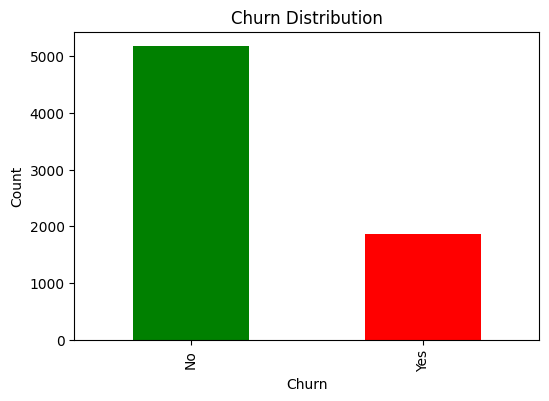

In [13]:
# Visualize churn distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [15]:
# No -> 0 Yes -> 1
df['Churn'] = encoder.fit_transform(df['Churn'])

In [16]:
# Check numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
print("\nNumerical features statistics:")
print(df[numerical_cols].describe())


Numerical features statistics:
            tenure  MonthlyCharges  SeniorCitizen
count  7043.000000     7043.000000    7043.000000
mean     32.371149       64.761692       0.162147
std      24.559481       30.090047       0.368612
min       0.000000       18.250000       0.000000
25%       9.000000       35.500000       0.000000
50%      29.000000       70.350000       0.000000
75%      55.000000       89.850000       0.000000
max      72.000000      118.750000       1.000000


In [17]:
# Check categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical features:", categorical_cols)


Categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\Lalit Sharma\AppData\Local\Temp\ipykernel_27844\610300434.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [18]:
# 1. Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 2. Feature engineering - create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                            bins=[0, 12, 24, 48, 72, 100], 
                            labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr', '6+yr'])
df['tenure_group'] = LabelEncoder().fit_transform(df['tenure_group'])


In [19]:
# categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# df_encoded['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72, 100], labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr', '6+yr'])
# df_encoded = pd.get_dummies(df_encoded, columns=['tenure_group'], prefix='tenure')

### Feature Selection

### 1. Correlation Matrix

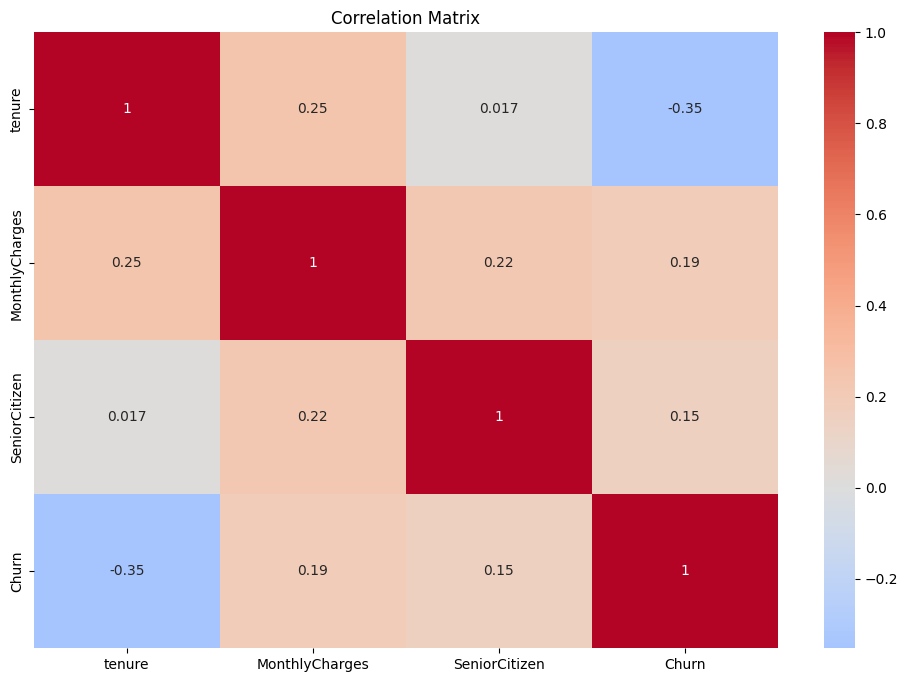

In [20]:
# Correlation analysis
import seaborn as sns

plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols + ['Churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [21]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group'],
      dtype='str')

In [22]:
df = df.drop(['TotalCharges','customerID'],axis=1)

In [23]:
df.columns.value_counts().sum()

np.int64(20)

In [24]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Churn', 'tenure_group'],
      dtype='str')

In [25]:
X =  df[df.columns[:]].sample(5)
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,tenure_group
762,1,0,1,0,3,1,0,1,0,0,0,0,0,0,0,1,2,70.30,1,0
1459,0,0,0,0,60,1,0,1,0,2,2,0,2,2,2,1,2,99.65,0,3
5365,1,0,0,1,62,1,0,2,1,1,1,1,1,1,2,0,0,20.00,0,3
5872,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,1,2,69.65,1,0
6544,0,1,0,0,42,1,2,1,0,2,2,0,2,2,0,1,0,104.75,1,2


### 2. Wrapper Methods - Forward/Backward Selection


In [26]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier

# Forward Feature Selection
sfs = SequentialFeatureSelector(
    RandomForestClassifier(n_estimators=100, random_state=42),
    k_features=15,
    forward=True,
    floating=False,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
X =  df.drop(['Churn'], axis=1)
y = df['Churn']
sfs.fit(X, y)

print("Forward Selection Results:")
print(f"Selected features: {sfs.k_feature_names_}")
print(f"Best CV score: {sfs.k_score_}")

Forward Selection Results:
Selected features: ('SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'tenure_group')
Best CV score: 0.8161501886564757


### 3. Embedded Methods (L1 Regularization (Lasso))

c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pena

Lasso Selected Features:
['SeniorCitizen', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'Contract', 'PaperlessBilling']

Lasso Coefficients:
             feature  coefficient  abs_coef
5       PhoneService    -0.795070  0.795070
14          Contract    -0.679001  0.679001
15  PaperlessBilling     0.311755  0.311755
8     OnlineSecurity    -0.260136  0.260136
11       TechSupport    -0.249258  0.249258
1      SeniorCitizen     0.202264  0.202264
7    InternetService     0.177024  0.177024
3         Dependents    -0.139569  0.139569
9       OnlineBackup    -0.113544  0.113544
6      MultipleLines     0.084372  0.084372


C:\Users\Lalit Sharma\AppData\Local\Temp\ipykernel_27844\1371862312.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_lasso_features, x='abs_coef', y='feature', palette='coolwarm')


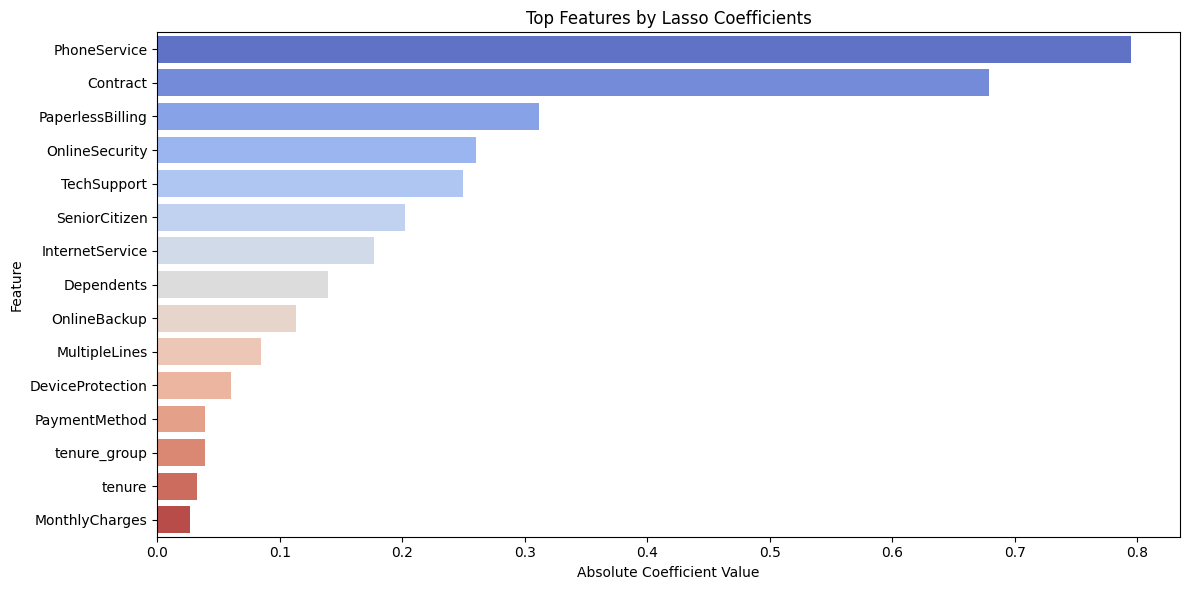

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# L1 Regularization for feature selection
lasso = LogisticRegression(penalty='l1', 
                        C=0.1,  # Regularization strength
                        solver='saga',
                        random_state=42,
                        max_iter=1000)
lasso.fit(X, y)

# Select features with non-zero coefficients
selector = SelectFromModel(lasso, threshold='median')
selector.fit(X, y)

lasso_selected = X.columns[selector.get_support()].tolist()
print("Lasso Selected Features:")
print(lasso_selected)

# View coefficients
lasso_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_[0],
    'abs_coef': np.abs(lasso.coef_[0])
}).sort_values('abs_coef', ascending=False)

print("\nLasso Coefficients:")
print(lasso_coef[lasso_coef['coefficient'] != 0].head(10))


# Visualize top features
plt.figure(figsize=(12, 6))
top_lasso_features = lasso_coef[lasso_coef['coefficient'] != 0].head(15)
sns.barplot(data=top_lasso_features, x='abs_coef', y='feature', palette='coolwarm')
plt.title('Top Features by Lasso Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [28]:
X['InternetService'].unique()

array([0, 1, 2])

In [29]:
X['SeniorCitizen'].unique()

array([0, 1])

In [30]:
X['Partner'].unique()

array([1, 0])

In [31]:
X['Dependents'].unique()

array([0, 1])

In [32]:
X['MonthlyCharges'] = X['MonthlyCharges'].astype(int)

In [33]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            7043 non-null   int64
 1   SeniorCitizen     7043 non-null   int64
 2   Partner           7043 non-null   int64
 3   Dependents        7043 non-null   int64
 4   tenure            7043 non-null   int64
 5   PhoneService      7043 non-null   int64
 6   MultipleLines     7043 non-null   int64
 7   InternetService   7043 non-null   int64
 8   OnlineSecurity    7043 non-null   int64
 9   OnlineBackup      7043 non-null   int64
 10  DeviceProtection  7043 non-null   int64
 11  TechSupport       7043 non-null   int64
 12  StreamingTV       7043 non-null   int64
 13  StreamingMovies   7043 non-null   int64
 14  Contract          7043 non-null   int64
 15  PaperlessBilling  7043 non-null   int64
 16  PaymentMethod     7043 non-null   int64
 17  MonthlyCharges    7043 non-null   int64
 18 

In [34]:
# X[['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'tenure_group']].value_counts()

### 3. Split Data into train test split

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [42]:
lrc = LogisticRegression(solver='lbfgs', penalty='l2', max_iter=1000)
svc = SVC(kernel='sigmoid',gamma=1.0)
# mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [43]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    # 'NB' : mnb,
    'LR' : lrc,
    'DT' : dtc,
    'RF' : rfc,
    'AdaBoost' : abc,
    'BgC' :bc,
    'ETC' : etc,
    'GBDT' : gbc,
    'Xgb' : xgb
}

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score

X = df[['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'tenure_group']]
y = df['Churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [45]:
train_classifier(svc,X_train,y_train,X_test,y_test)

c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.7530163236337828, 0.0)

In [46]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For",name)
    print("Accuracy is :",current_accuracy)
    print("Precision is :",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


For SVC
Accuracy is : 0.7530163236337828
Precision is : 0.0
For KN
Accuracy is : 0.7750177430801988
Precision is : 0.5474006116207951
For LR
Accuracy is : 0.8041163946061036
Precision is : 0.6285714285714286
For DT
Accuracy is : 0.7835344215755855
Precision is : 0.5558441558441558
For RF
Accuracy is : 0.7970191625266146
Precision is : 0.6131386861313869
For AdaBoost
Accuracy is : 0.8048261178140526
Precision is : 0.6308243727598566
For BgC
Accuracy is : 0.7963094393186657
Precision is : 0.6033898305084746
For ETC
Accuracy is : 0.7707594038325053
Precision is : 0.5423728813559322
For GBDT
Accuracy is : 0.8147622427253371
Precision is : 0.6719367588932806
For Xgb
Accuracy is : 0.8055358410220014
Precision is : 0.6293706293706294


In [47]:
performance_df = pd.DataFrame({'Algorithms':clfs.keys(),'Accuraccy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [48]:
performance_df

,Algorithms,Accuraccy,Precision
8,GBDT,0.814762,0.671937
5,AdaBoost,0.804826,0.630824
9,Xgb,0.805536,0.629371
2,LR,0.804116,0.628571
4,RF,0.797019,0.613139
6,BgC,0.796309,0.603390
3,DT,0.783534,0.555844
1,KN,0.775018,0.547401
7,ETC,0.770759,0.542373
0,SVC,0.753016,0.000000


In [49]:
performance_df1 = pd.melt(performance_df, id_vars='Algorithms')

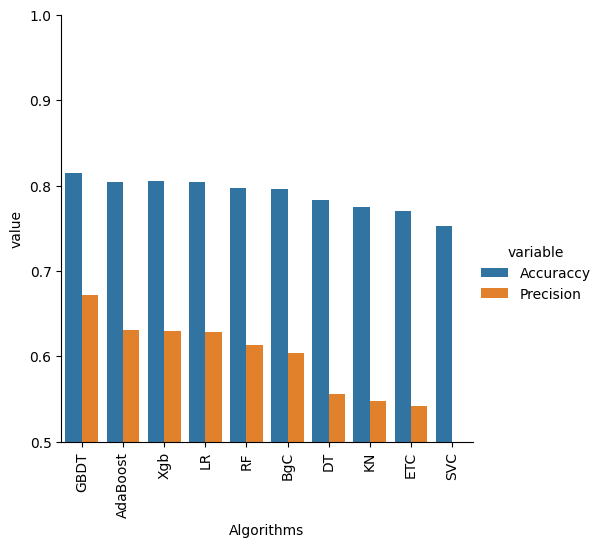

In [50]:
sns.catplot(x= 'Algorithms', y= 'value',hue = 'variable', data=performance_df1, kind='bar', height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')

plt.show()


### Model Improvement

In [51]:
temp_df = pd.DataFrame({'Algorithms':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores})

In [52]:
performance_df.merge(temp_df,on='Algorithms')

,Algorithms,Accuraccy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,GBDT,0.814762,0.671937,0.814762,0.671937
1,AdaBoost,0.804826,0.630824,0.804826,0.630824
2,Xgb,0.805536,0.629371,0.805536,0.629371
3,LR,0.804116,0.628571,0.804116,0.628571
4,RF,0.797019,0.613139,0.797019,0.613139
5,BgC,0.796309,0.603390,0.796309,0.603390
6,DT,0.783534,0.555844,0.783534,0.555844
7,KN,0.775018,0.547401,0.775018,0.547401
8,ETC,0.770759,0.542373,0.770759,0.542373
9,SVC,0.753016,0.000000,0.753016,0.000000


In [53]:
new_df = pd.DataFrame({'Algorithms':clfs.keys(),'Accuracy_Scaled':accuracy_scores,'Precision_Scaled':precision_scores})

In [54]:
new_df_scaled = new_df.merge(temp_df,on='Algorithms')

In [55]:
new_df_scaled

,Algorithms,Accuracy_Scaled,Precision_Scaled,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.753016,0.000000,0.753016,0.000000
1,KN,0.775018,0.547401,0.775018,0.547401
2,LR,0.804116,0.628571,0.804116,0.628571
3,DT,0.783534,0.555844,0.783534,0.555844
4,RF,0.797019,0.613139,0.797019,0.613139
5,AdaBoost,0.804826,0.630824,0.804826,0.630824
6,BgC,0.796309,0.603390,0.796309,0.603390
7,ETC,0.770759,0.542373,0.770759,0.542373
8,GBDT,0.814762,0.671937,0.814762,0.671937
9,Xgb,0.805536,0.629371,0.805536,0.629371


In [67]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier

svc = SVC(kernel='rbf',gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

In [68]:
voting = VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [69]:
voting.fit(X_train,y_train)

c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[SVC(gamma=1.0...bability=True), MultinomialNB(), ExtraTreesCla...andom_state=2)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['SeniorCitizen','Partner','Dependents',...,'PaymentMethod', 'MonthlyCharges','tenure_group']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [70]:
y_pred = voting.predict(X_test)
print('Accuracy',accuracy_score(y_test,y_pred))
print('Precision',precision_score(y_test,y_pred))

Accuracy 0.7629524485450674
Precision 0.5177664974619289


In [71]:
# Applying Stacking
estimators = [('svm',svc),('nb',mnb),('et',etc)]
final_estimator = RandomForestClassifier()

In [72]:
from sklearn.ensemble import StackingClassifier

In [73]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator, cv=5)

In [74]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print('Accuracy',accuracy_score(y_test,y_pred))
print('Precision',precision_score(y_test,y_pred))

c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lalit Sharma\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be r

Accuracy 0.7778566359119943
Precision 0.5618374558303887


In [75]:
import pickle

# Save feature columns (the one-hot encoded column names)
feature_columns = X_train.columns.tolist()

# Save feature columns
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(gbc, f)